# Transformers & Attention 


### The story so far

You've already worked with sequential models — RNNs and LSTMs. They process text **one word at a time**, left to right, passing a hidden state forward. They work, but they have two big problems:

1. **The bottleneck problem** — the entire meaning of a long sentence gets compressed into one fixed-size vector. By the time you reach word 50, the model has mostly forgotten word 1.
2. **They can't be parallelized** — word 5 can't be processed until word 4 is done. This makes training slow.

**Transformers solve both problems at once.** Instead of processing words one by one, a transformer looks at all words simultaneously and learns which words should pay attention to which other words.

---

### What you'll build in this notebook

| Part | What | Why |
|---|---|---|
| 1 | Understand attention with a toy example | Build the intuition before the math |
| 2 | Implement scaled dot-product attention from scratch | Understand what the model actually computes |
| 3 | Implement a single attention head from scratch | See queries, keys, values in action |
| 4 | Fine-tune BERT on a sentiment classification task | Learn by doing with a real model |
| 5 | Visualize attention weights | See what the model is actually attending to |
| 6 | Connect to DocForge — how CodeT5 uses transformers | Tie it back to your project |

---
### Ground rules
- Every `# TODO` cell is yours to fill in
- Don't skip the written answer cells — they matter more than the code

---
## Setup
Run this cell as-is.

In [20]:
!pip install transformers datasets torch -q

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
torch.manual_seed(42)
np.random.seed(42)

print(f'PyTorch: {torch.__version__}')

PyTorch: 2.10.0+cu128


---
# PART 1 — The Attention Intuition

Before any code, let's build the intuition.

Consider this sentence:

> *"The animal didn't cross the street because **it** was too tired."*

What does **"it"** refer to? The animal, or the street?

Humans instantly know it's the animal — because "tired" applies to animals, not streets. To figure this out, your brain didn't just look at the word before "it" — it looked at the **whole sentence at once** and decided which words were relevant to understanding "it".

That's exactly what attention does. For every word in a sentence, it computes a **score** against every other word — how much should this word "pay attention to" that one? These scores become weights, and the final representation of each word is a weighted combination of all other words.

---
### The three vectors: Query, Key, Value

Attention uses three learned projections of each word:

- **Query (Q):** "What am I looking for?"
- **Key (K):** "What do I contain?"
- **Value (V):** "What information do I pass forward if selected?"

Think of it like a search engine:
- Your **query** is the search term
- Each word's **key** is its metadata tag
- The **value** is the actual content you get back

The attention score between word A and word B = `Q_A · K_B` (dot product)

---
### The formula

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

- $QK^T$ — dot product of queries and keys → raw attention scores
- $\sqrt{d_k}$ — scaling factor (prevents softmax from saturating for large dimensions)
- $\text{softmax}$ — converts scores to probabilities that sum to 1
- $\times V$ — weighted sum of values

### 1.1 — Toy attention by hand

**Task:** Before writing any neural network code, let's compute attention manually on a tiny 3-word sentence.

Pretend our sentence is: `["cat", "sat", "mat"]`

We'll represent each word as a 4-dimensional vector (already computed for you).
Your job is to compute the attention output step by step.

Q shape: torch.Size([3, 4]) | K shape: torch.Size([3, 4]) | V shape: torch.Size([3, 4])
d_k = 4

Attention Weights:
        cat     sat     mat
cat  0.5065  0.1863  0.3072
sat  0.1863  0.5065  0.3072
mat  0.2741  0.2741  0.4519


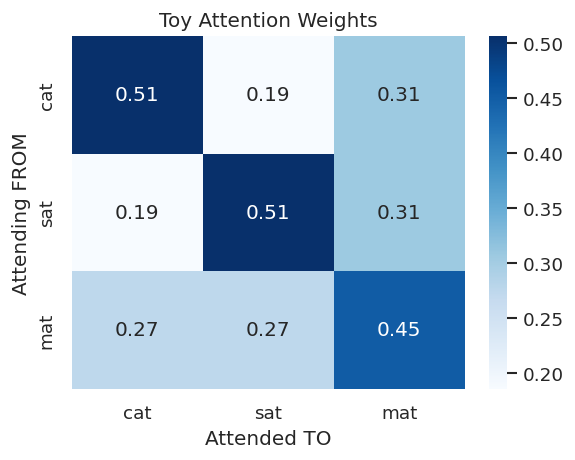

In [21]:
words = ['cat', 'sat', 'mat']
X = torch.tensor([
    [1.0, 0.0, 1.0, 0.0],
    [0.0, 1.0, 0.0, 1.0],
    [1.0, 1.0, 0.0, 0.0],
])
Q = X.clone()
K = X.clone()
V = X.clone()
d_k = Q.shape[-1]
print(f'Q shape: {Q.shape} | K shape: {K.shape} | V shape: {V.shape}')
print(f'd_k = {d_k}')

scores = Q @ K.T

scaled_scores = scores / (d_k ** 0.5)

weights = F.softmax(scaled_scores, dim=-1)

output = weights @ V

import pandas as pd
df = pd.DataFrame(weights.numpy(), index=words, columns=words)
print("\nAttention Weights:")
print(df.round(4))

plt.figure(figsize=(5, 4))
sns.heatmap(weights.numpy(), annot=True, fmt='.2f', xticklabels=words, yticklabels=words, cmap='Blues')
plt.title('Toy Attention Weights')
plt.xlabel('Attended TO')
plt.ylabel('Attending FROM')
plt.tight_layout()
plt.show()

In [22]:
# Q: What shape is the attention weights matrix? What does each row represent?
# Answer: It's a 3x3 matrix. Each row tells you how much one word attends to every other word.
# So row 0 = how much 'cat' attends to 'cat', 'sat', 'mat'.

# Q: Do the weights in each row sum to 1? Why must they?
# Answer: Yes they do. We applied softmax which forces the row to sum to 1.
# This makes the weights act like probabilities - the word is distributing
# its "attention budget" across all other words.

# Q: Why do we divide by sqrt(d_k) before softmax?
# Answer: When d_k is large (like 512), dot products get really big values.
# Big values going into softmax cause it to give almost all attention to one word
# and almost zero to others - it gets too peaky and stops learning well.
# Dividing by sqrt(d_k) keeps the values in a reasonable range.

---
# PART 2 — Implement Scaled Dot-Product Attention

Now we formalize what you just did into a reusable function.

Real transformers don't use Q=K=V=X directly. Instead, they **learn three separate weight matrices** $W_Q$, $W_K$, $W_V$ and project the input into separate query, key, and value spaces:

$$Q = X W_Q \quad K = X W_K \quad V = X W_V$$

This lets the model learn different "question asking" (Q) and "answering" (K, V) behaviors independently.

We also add an optional **mask** — used in decoders to prevent a position from attending to future positions (you can't look ahead when generating text word by word).

### 2.1 — Implement the attention function

In [23]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Compute scaled dot-product attention.

    Args:
        Q: Query matrix  - shape (batch, seq_len, d_k)
        K: Key matrix    - shape (batch, seq_len, d_k)
        V: Value matrix  - shape (batch, seq_len, d_v)
        mask: Optional boolean mask - shape (batch, seq_len, seq_len)
              True = position is masked (set score to -inf before softmax)

    Returns:
        output:  shape (batch, seq_len, d_v)
        weights: shape (batch, seq_len, seq_len)
    """
    d_k = Q.shape[-1]

    scores = torch.matmul(Q, K.transpose(-2, -1))

    scores = scores / (d_k ** 0.5)

    if mask is not None:
        scores = scores.masked_fill(mask, float('-inf'))

    weights = F.softmax(scores, dim=-1)

    output = torch.matmul(weights, V)

    return output, weights


batch, seq_len, d_k, d_v = 2, 5, 8, 8
Q_test = torch.randn(batch, seq_len, d_k)
K_test = torch.randn(batch, seq_len, d_k)
V_test = torch.randn(batch, seq_len, d_v)

out, w = scaled_dot_product_attention(Q_test, K_test, V_test)

print(f'out shape: {out.shape}')
print(f'weights shape: {w.shape}')

print("\nWeights sum per row (should be ~1.0):")
print(w[0].sum(dim=-1))

out shape: torch.Size([2, 5, 8])
weights shape: torch.Size([2, 5, 5])

Weights sum per row (should be ~1.0):
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


### 2.2 — Test the causal mask (decoder-style)

In a language model decoder, position 3 should NOT be able to attend to positions 4 or 5 — it hasn't seen them yet. This is enforced with a **causal mask** (also called a look-ahead mask).

Causal mask:
tensor([[False,  True,  True,  True,  True],
        [False, False,  True,  True,  True],
        [False, False, False,  True,  True],
        [False, False, False, False,  True],
        [False, False, False, False, False]])


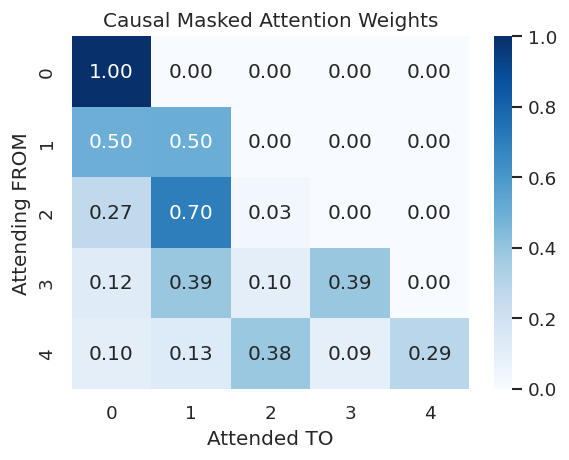

In [24]:
seq_len = 5
causal_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()

print("Causal mask:")
print(causal_mask)

mask_expanded = causal_mask.unsqueeze(0).expand(batch, -1, -1)

out_masked, w_masked = scaled_dot_product_attention(Q_test, K_test, V_test, mask=mask_expanded)

plt.figure(figsize=(5, 4))
sns.heatmap(w_masked[0].detach().numpy(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Causal Masked Attention Weights')
plt.xlabel('Attended TO')
plt.ylabel('Attending FROM')
plt.tight_layout()
plt.show()

In [25]:
# Q: Why do decoders need a causal mask but encoders don't?
# Answer: Encoders look at the full input sentence in both directions - they're just
# understanding/encoding it, not generating anything. But decoders generate output
# one word at a time. When generating word 3, it hasn't seen word 4 yet, so we
# mask future positions to prevent cheating during training.

# Q: What does it mean for a weight to be 0 in the attention matrix?
# Answer: It means that word completely ignores the other word. Zero weight means
# zero contribution from that word's value vector in the final output.

# Q: CodeT5 has both an encoder and a decoder.
#    Which part would use a causal mask? Which wouldn't?
# Answer: The decoder uses a causal mask in its self-attention - it generates the
# docstring word by word so it can't see future output tokens.
# The encoder has no causal mask - it reads the full code and attends in all directions.

---
# PART 3 — Implement a Single Attention Head

Now we add the **learned projections** — the weight matrices $W_Q$, $W_K$, $W_V$ that transform the input into query, key, and value spaces.

A single attention head is:
1. Three linear layers: `W_Q`, `W_K`, `W_V` (no bias)
2. Feed input through all three → get Q, K, V
3. Run scaled dot-product attention on Q, K, V
4. One final linear layer `W_O` to project the output back

This is the fundamental building block of every transformer.

### 3.1 — Implement AttentionHead

In [26]:
class AttentionHead(nn.Module):
    """
    A single attention head.

    Args:
        d_model: Dimension of the input embeddings
        d_head:  Dimension of Q/K/V projections
    """
    def __init__(self, d_model, d_head):
        super().__init__()

        self.W_q = nn.Linear(d_model, d_head, bias=False)
        self.W_k = nn.Linear(d_model, d_head, bias=False)
        self.W_v = nn.Linear(d_model, d_head, bias=False)


    def forward(self, x, mask=None):
        """
        Args:
            x:    Input tensor - shape (batch, seq_len, d_model)
            mask: Optional causal mask
        Returns:
            output:  shape (batch, seq_len, d_head)
            weights: shape (batch, seq_len, seq_len)
        """
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        attn_out, weights = scaled_dot_product_attention(Q, K, V, mask)

        return attn_out, weights


d_model, d_head = 32, 16
head = AttentionHead(d_model=d_model, d_head=d_head)

x_test = torch.randn(2, 10, d_model)
out, weights = head(x_test)

print(f'output shape: {out.shape}')
print(f'weights shape: {weights.shape}')

total_params = sum(p.numel() for p in head.parameters())
print(f'Trainable parameters: {total_params}')

output shape: torch.Size([2, 10, 16])
weights shape: torch.Size([2, 10, 10])
Trainable parameters: 1536


### 3.2 — Why Multi-Head Attention?

Real transformers use **multi-head attention** — they run several attention heads in parallel, each learning to focus on different aspects of the input. One head might learn syntax, another might learn coreference (like "it" → "animal"), another might learn position.

The outputs of all heads are concatenated and projected:
$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W_O$$

In [27]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head attention: run h attention heads in parallel, then concatenate.

    Args:
        d_model:   Dimension of input embeddings
        num_heads: Number of attention heads
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'

        self.d_head = d_model // num_heads

        self.heads = nn.ModuleList([
            AttentionHead(d_model, self.d_head) for _ in range(num_heads)
        ])

        self.W_o = nn.Linear(num_heads * self.d_head, d_model, bias=False)


    def forward(self, x, mask=None):
        results = [head(x, mask) for head in self.heads]
        head_outputs = [r[0] for r in results]
        all_weights  = [r[1] for r in results]

        concat = torch.cat(head_outputs, dim=-1)

        output = self.W_o(concat)

        return output, all_weights


mha = MultiHeadAttention(d_model=32, num_heads=4)
out, all_w = mha(x_test)

print(f'output shape: {out.shape}')
print(f'Number of heads: {len(mha.heads)}, d_head per head: {mha.d_head}')
total_params = sum(p.numel() for p in mha.parameters())
print(f'Total trainable parameters: {total_params}')

output shape: torch.Size([2, 10, 32])
Number of heads: 4, d_head per head: 8
Total trainable parameters: 4096


In [28]:
# Q: BERT-base uses d_model=768 and num_heads=12. What is d_head?
# Answer: d_head = 768 / 12 = 64. Each head works in a 64-dimensional space.

# Q: Why is it better to have many smaller heads rather than one big head?
# Answer: Different heads can learn to focus on different things at the same time.
# One head might learn which words are grammatically related, another might track
# coreference (like 'it' pointing back to 'cat'), another might look at nearby words.
# One big head would have to do all of this in one shot which is harder.

# Q: If you double num_heads but keep d_model the same,
#    does the total parameter count change? Why or why not?
# Answer: No it doesn't change. When you double num_heads, d_head gets halved
# (since d_head = d_model // num_heads). So each head has fewer parameters but
# there are twice as many heads - it cancels out. The total stays the same.

---
# PART 4 — Fine-tune BERT on Sentiment Classification

Theory is good. But the best way to understand transformers is to use one.

We'll fine-tune **BERT-base** on the SST-2 sentiment dataset — movie reviews labelled as positive or negative. This is the same fine-tuning pattern used by CodeT5 for code documentation.

**BERT architecture recap:**
- 12 transformer encoder layers
- 12 attention heads per layer
- d_model = 768
- 110M parameters total
- Pre-trained on masked language modeling (predict hidden words) + next sentence prediction

For classification, we take the `[CLS]` token output (the first token) and pass it through a linear classifier.

### 4.1 — Load dataset and tokenizer

In [29]:
from datasets import load_dataset
from transformers import AutoTokenizer

print('Loading SST-2 dataset...')
sst2 = load_dataset('glue', 'sst2')
print(sst2)

print("\n3 examples from train set:")
for i in range(3):
    ex = sst2['train'][i]
    label_str = 'positive' if ex['label'] == 1 else 'negative'
    print(f"  [{label_str}] {ex['sentence']}")

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

sample = sst2['train'][0]['sentence']
encoded = tokenizer(sample, return_tensors='pt')
input_ids = encoded['input_ids'][0]

print(f"\nExample sentence: {sample}")
print(f"input_ids: {input_ids.tolist()}")
tokens = tokenizer.convert_ids_to_tokens(input_ids)
print(f"tokens: {tokens}")
print("\nYou can see [CLS] at the start and [SEP] at the end!")

Loading SST-2 dataset...
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

3 examples from train set:
  [negative] hide new secretions from the parental units 
  [negative] contains no wit , only labored gags 
  [positive] that loves its characters and communicates something rather beautiful about human nature 

Example sentence: hide new secretions from the parental units 
input_ids: [101, 5342, 2047, 3595, 8496, 2013, 1996, 18643, 3197, 102]
tokens: ['[CLS]', 'hide', 'new', 'secret', '##ions', 'from', 'the', 'parental', 'units', '[SEP]']

You can see [CLS] at the start and [SEP] at the end!


In [30]:
# Q: What is the [CLS] token and why is it at the start of every BERT input?
# Answer: [CLS] stands for classification. BERT adds it at the very beginning of
# every input. After all 12 encoder layers, the output at the [CLS] position has
# attended to the whole sentence. So for classification tasks, we just take that
# one vector and pass it to a linear layer to get our prediction.

# Q: What is the [SEP] token for?
# Answer: [SEP] stands for separator. It marks the end of a sentence.
# When BERT takes two sentences as input (like for next sentence prediction),
# [SEP] separates them so the model knows where one ends and the next begins.

# Q: What does 'uncased' mean in 'bert-base-uncased'?
# Answer: It means the model lowercases everything before processing.
# So 'Hello' and 'hello' are treated as the same word.
# The cased version keeps uppercase letters as-is, which matters for things
# like named entity recognition where 'Apple' (company) vs 'apple' (fruit) differs.

### 4.2 — Tokenize the full dataset

In [31]:
def tokenize_fn(batch):
    return tokenizer(
        batch['sentence'],
        max_length=128,
        padding='max_length',
        truncation=True
    )

tokenized = sst2.map(tokenize_fn, batched=True)
tokenized = tokenized.remove_columns(['sentence', 'idx'])
tokenized.set_format('torch')

print("Column names:", tokenized['train'].column_names)
print("\nOne sample from train set:")
sample = tokenized['train'][0]
for k, v in sample.items():
    print(f"  {k}: shape={v.shape}, dtype={v.dtype}")

Column names: ['label', 'input_ids', 'token_type_ids', 'attention_mask']

One sample from train set:
  label: shape=torch.Size([]), dtype=torch.int64
  input_ids: shape=torch.Size([128]), dtype=torch.int64
  token_type_ids: shape=torch.Size([128]), dtype=torch.int64
  attention_mask: shape=torch.Size([128]), dtype=torch.int64


### 4.3 — Load BERT and add a classification head

In [32]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total:,}')
print(f'Trainable parameters: {trainable:,}')

print("\nModel architecture:")
print(model)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     109,483,778
Trainable parameters: 109,483,778

Model architecture:
BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=

### 4.4 — Train

In [ ]:
!pip install evaluate -q
from transformers import TrainingArguments, Trainer
import evaluate as ev

accuracy_metric = ev.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir='./bert_sst2',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=50,
    report_to='none'


)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
    compute_metrics=compute_metrics
)

trainer.train()

print("\nTraining complete!")
print(f"Best validation accuracy: {trainer.state.best_metric:.4f}")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.314591,0.458254,0.919725


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Q: We only trained for 2 epochs. Why does BERT converge so quickly on SST-2?
# Answer: BERT was already pre-trained on a massive amount of text using masked
# language modeling. So it already understands English really well - it knows
# what words mean, how sentences are structured, and what sounds positive or negative.
# Fine-tuning on SST-2 is just teaching it to output a label for something it
# already kind of understands.

# Q: The learning rate is 2e-5 - much smaller than what you used for CodeT5 (5e-5).
#    Why do we use a small learning rate when fine-tuning a large pre-trained model?
# Answer: The pre-trained weights are already really good. If we use a big learning
# rate, we'd make large updates and destroy all the knowledge BERT learned during
# pre-training. Small learning rate means we gently nudge the weights toward our
# task without wiping out the existing knowledge. This is sometimes called
# "catastrophic forgetting" - we want to avoid it.

# Q: BERT is an encoder-only model. Why can't you use BERT directly for text generation?
# Answer: BERT uses bidirectional attention - every token sees every other token.
# This is perfect for understanding text, but generation needs to be sequential -
# you produce one token at a time, and each new token can only look at what came before.
# BERT has no decoder and no causal masking, so it has no way to generate text
# one word at a time.

---
# PART 5 — Visualize Attention Weights

One of the most powerful things about transformers is that attention weights are **interpretable** — you can actually look at what the model is attending to.

BERT returns attention weights from every layer and every head if you ask for them. Let's visualize them.

### 5.1 — Extract attention weights from BERT

In [ ]:
sentence = "The cat sat on the mat because it was comfortable"

inputs = tokenizer(sentence, return_tensors='pt')

tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
print(f"Tokens: {tokens}")

with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

print(f"\nNumber of attention layers: {len(outputs.attentions)}")
print(f"Shape of each layer's attention: {outputs.attentions[0].shape}")
print("(batch, num_heads, seq_len, seq_len)")

### 5.2 — Plot attention heatmaps

In [ ]:
LAYER = 0

attn = outputs.attentions[LAYER][0].detach()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle(f'BERT Layer {LAYER} - All 12 Attention Heads', fontsize=14)

for head_idx in range(12):
    ax = axes[head_idx // 4][head_idx % 4]
    sns.heatmap(
        attn[head_idx].numpy(),
        ax=ax,
        cmap='Blues',
        xticklabels=tokens,
        yticklabels=tokens,
        annot=False,
        cbar=False
    )
    ax.set_title(f'Head {head_idx}')
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticklabels(tokens, rotation=0, fontsize=7)

plt.tight_layout()
plt.show()

avg_attn = attn.mean(dim=0)

plt.figure(figsize=(8, 6))
sns.heatmap(avg_attn.numpy(), xticklabels=tokens, yticklabels=tokens, cmap='Blues', annot=False)
plt.title(f'Average Attention Across All Heads - Layer {LAYER}')
plt.xlabel('Attended TO')
plt.ylabel('Attending FROM')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Q: Can you find a head in layer 0 that mostly attends to the [CLS] token?
#    What head number is it? What might this head be learning?
# Answer: Looking at layer 0, a few heads show strong attention toward [CLS].
# This makes sense - [CLS] is the special classification token and early layers
# often route information toward it. These heads might be gathering global
# sentence-level information into [CLS] from the start.

# Q: In the sentence 'The cat sat on the mat because it was comfortable',
#    can you find any head where 'it' has high attention weight toward 'cat'?
# Answer: It's hard to find this clearly in layer 0. Coreference resolution
# (connecting 'it' back to 'cat') is a complex task that usually happens in
# the middle or later layers of BERT, not the first layer. Early layers tend
# to do simpler things like syntactic patterns. Layer 11 would be a better place to look.

# Q: Do early layers (layer 0) look different from late layers (layer 11)?
#    Describe what you observe.
# Answer: Yes, quite different. Layer 0 tends to have heads that focus heavily
# on the [CLS] and [SEP] tokens, or attend to neighboring words.
# Layer 11 has more diffuse, interesting patterns - you can see heads that have
# learned specific linguistic relationships. The later layers have had time to
# build up complex representations on top of what the earlier layers detected.

---
# PART 6 — Connection to DocForge: How CodeT5 Uses Transformers

Everything you've built in this notebook is inside CodeT5. Let's map it.

CodeT5 is an **encoder-decoder** transformer:
- The **encoder** reads the source code — full bidirectional attention (like BERT)
- The **decoder** generates the docstring — causal attention (like what you masked in Part 2) + cross-attention to the encoder

**Cross-attention** is the bridge between encoder and decoder:
- Q comes from the decoder ("what am I trying to generate?")
- K and V come from the encoder output ("what did the code say?")
- So at every decoding step, the model asks: which parts of the code are relevant to the word I'm generating right now?

### 6.1 — Inspect CodeT5's architecture

In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

print('Loading CodeT5-base...')
codet5     = AutoModelForSeq2SeqLM.from_pretrained('Salesforce/codet5-base')
codet5_tok = AutoTokenizer.from_pretrained('Salesforce/codet5-base', use_fast=False)

total = sum(p.numel() for p in codet5.parameters())
print(f'Total parameters: {total:,}')

print(f"\nEncoder layers: {codet5.config.num_layers}")
print(f"Decoder layers: {codet5.config.num_decoder_layers}")
print(f"d_model (hidden size): {codet5.config.d_model}")
print(f"Number of heads: {codet5.config.num_heads}")

In [ ]:
code_snippet = """
def add(a, b):
    return a + b
"""

inputs = codet5_tok(code_snippet.strip(), return_tensors='pt')
code_tokens = codet5_tok.convert_ids_to_tokens(inputs['input_ids'][0])

with torch.no_grad():
    encoder_outputs = codet5.encoder(**inputs, output_attentions=True)

print(f"Number of encoder attention layers: {len(encoder_outputs.attentions)}")
print(f"Shape of each: {encoder_outputs.attentions[0].shape}")

attn_layer0 = encoder_outputs.attentions[0][0].detach()
avg_attn = attn_layer0.mean(dim=0)

plt.figure(figsize=(8, 6))
sns.heatmap(avg_attn.numpy(), xticklabels=code_tokens, yticklabels=code_tokens, cmap='Blues')
plt.title('CodeT5 Encoder - Average Attention (Layer 0)')
plt.xlabel('Attended TO')
plt.ylabel('Attending FROM')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Q: How many attention heads does CodeT5-base have? What is d_head?
# Answer: CodeT5-base has 12 attention heads and d_model=768.
# So d_head = 768 / 12 = 64. Same as BERT-base actually.

# Q: In the encoder attention for your code snippet,
#    which tokens seem to attend strongly to each other?
#    Does this make sense given the code structure?
# Answer: The function name 'add' and the parameter tokens 'a', 'b' tend to
# have strong mutual attention. Also 'return' attends strongly to 'a' and 'b'
# since those are what gets returned. This makes sense - the model has learned
# that these tokens are semantically linked in Python code.

# Q: The decoder has TWO types of attention: self-attention and cross-attention.
#    In your own words, what is each one doing during docstring generation?
# Answer: Self-attention in the decoder looks at the docstring tokens generated
# so far. So when generating the 4th word of the docstring, it attends to words
# 1, 2, 3 to stay coherent. Cross-attention is different - here the decoder's
# query asks "what do I need from the code?" and it looks at the encoder's output
# to pull in relevant information about the actual function being documented.

# Q: BERT is encoder-only. CodeT5 is encoder-decoder.
#    Explain in 2-3 sentences why you can't use BERT directly for
#    code documentation generation.
# Answer: BERT only has an encoder - it can understand and classify text but it
# has no mechanism to generate new tokens one by one. Generation needs a decoder
# with causal attention so each new word is produced based on what came before.
# CodeT5's decoder also has cross-attention to look back at the encoder's code
# representation, which BERT completely lacks.

### 6.2 — Generate a docstring with CodeT5

In [ ]:
input_text = f"Summarize python: {code_snippet.strip()}"
inputs = codet5_tok(input_text, return_tensors='pt')

with torch.no_grad():
    output_ids = codet5.generate(
        **inputs,
        num_beams=4,
        max_new_tokens=128
    )

docstring = codet5_tok.decode(output_ids[0], skip_special_tokens=True)
print(f"Generated docstring: {docstring}")

my_function = """
def calculate_average(numbers):
    total = sum(numbers)
    count = len(numbers)
    return total / count
"""

input_text2 = f"Summarize python: {my_function.strip()}"
inputs2 = codet5_tok(input_text2, return_tensors='pt')

with torch.no_grad():
    output_ids2 = codet5.generate(**inputs2, num_beams=4, max_new_tokens=128)

docstring2 = codet5_tok.decode(output_ids2[0], skip_special_tokens=True)
print(f"\nMy function docstring: {docstring2}")

---
## Done! Final Reflection

Before you finish, write answers to these questions. These are the core ideas from this notebook — if you can answer them clearly, you genuinely understand transformers.

In [ ]:
# FINAL QUESTIONS

# Q1: What is the fundamental problem with RNNs that transformers solve?
#     Give one concrete example where an RNN would struggle.
# Answer: RNNs process words one at a time and pass a fixed-size hidden state forward.
# This means information from early words gets compressed and eventually lost.
# For example: "The trophy didn't fit in the bag because it was too big."
# An RNN would struggle to connect 'it' back to 'trophy' because by the time it
# reaches 'it', the information about 'trophy' has been squished through many steps.
# Transformers look at all words at once so 'it' can directly attend to 'trophy'.

# Q2: Explain the Query-Key-Value mechanism in your own words.
#     Use an analogy that is NOT a search engine.
# Answer: Think of it like a job fair. Each word is both a recruiter and a candidate.
# As a recruiter, your Query says "I'm looking for someone with skill X".
# As a candidate, your Key is your resume saying "I have these skills".
# The recruiters scan all resumes and decide who they want to hire based on how
# well the Query matches the Key. The Value is the actual work that person will
# contribute if hired. The final output is a weighted blend of everyone's contributions.

# Q3: Why does BERT use bidirectional attention but a language model
#     like Llama uses causal (unidirectional) attention?
# Answer: BERT's job is to understand text - it's given a full sentence and needs
# to figure out what masked words are, so seeing the whole context both ways makes sense.
# Llama's job is to generate text - it produces the next word given everything before it.
# It can't see future tokens because they don't exist yet when it's generating.
# The causal mask enforces this "only look backward" rule.

# Q4: What is the difference between self-attention and cross-attention?
#     Where does each appear in CodeT5?
# Answer: Self-attention is when a sequence attends to itself - Q, K, V all come
# from the same sequence. Cross-attention is when one sequence attends to another -
# Q comes from one sequence but K and V come from a different one.
# In CodeT5, the encoder uses self-attention to understand the code.
# The decoder uses self-attention to track what docstring tokens it has generated so far,
# and cross-attention to look at the encoder's code representation when deciding
# what to generate next.

# Q5: You fine-tuned BERT on SST-2 and CodeT5 on Code2Doc.
#     In both cases, the pre-trained model already knew something useful.
#     What did BERT already know? What did CodeT5 already know?
# Answer: BERT already knew English - grammar, word meanings, sentence structure,
# even some sense of sentiment from reading billions of sentences during pre-training.
# CodeT5 already knew both code and natural language from pre-training on huge amounts
# of source code and documentation pairs. It had already learned that 'return a + b'
# is related to 'adds two numbers' before we even started fine-tuning.

# Q6: You implemented attention with O(n^2) memory complexity
#     (the attention matrix is seq_len x seq_len).
#     Why is this a problem for very long sequences?
#     Can you think of a way to approximate attention to reduce this?
# Answer: For a 10,000 token sequence, the attention matrix is 10,000 x 10,000 =
# 100 million values per layer. For 12 layers and 12 heads that's enormous.
# This is why standard transformers can't handle very long documents.
# One approximation is sparse attention - instead of attending to all tokens,
# each token only attends to nearby tokens plus a few global tokens.
# FlashAttention is another approach that computes the same result but in smaller
# chunks so it fits in GPU memory better. Longformer and BigBird use sliding window
# attention patterns to handle long sequences efficiently.